In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="whitegrid")
NAVY = '#1B2A4A'

df      = pd.read_csv('../data/processed/master_fact_table.csv')
RAW_PATH = r"D:\OneDrive - Indochine Textiles BD Ltd\ETL\rmg-supply-chain-etl\data\raw/"
OUT_PATH = r"D:\OneDrive - Indochine Textiles BD Ltd\ETL\rmg-supply-chain-etl\data\processed/"
monthly = pd.read_csv('../data/processed/monthly_summary.csv')
product = pd.read_csv('../data/processed/product_summary.csv')
factory = pd.read_csv('../data/processed/factory_summary.csv')

print(f"Master table: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Total Revenue: ${df['Total_Revenue'].sum():,.0f}")
print(f"Total Profit:  ${df['Gross_Profit'].sum():,.0f}")
print(f"Avg Delay Days: {df['Delay_Days'].mean():.1f}")
print(f"Overall Delay Rate: {df['Is_Delayed'].mean()*100:.1f}%")

Master table: (82463, 30)
Date range: 01/01/2024 → 31/12/2023
Total Revenue: $2,727,609,540
Total Profit:  $1,171,738,492
Avg Delay Days: 0.2
Overall Delay Rate: 36.0%


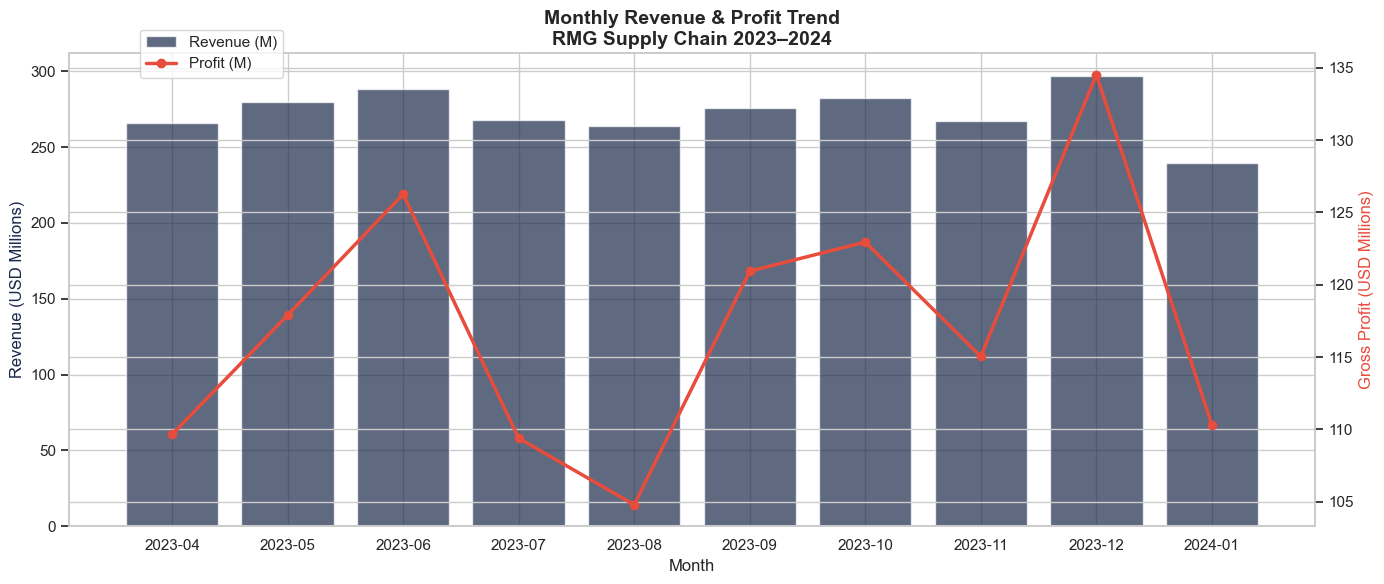

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(monthly['Month'], monthly['Revenue']/1e6,
        color=NAVY, alpha=0.7, label='Revenue (M)')
ax2.plot(monthly['Month'], monthly['Profit']/1e6,
         color='#e74c3c', marker='o', linewidth=2.5, label='Profit (M)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (USD Millions)', color=NAVY)
ax2.set_ylabel('Gross Profit (USD Millions)', color='#e74c3c')
ax1.set_title('Monthly Revenue & Profit Trend\nRMG Supply Chain 2023–2024',
              fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('../outputs/01_monthly_trend.png', dpi=150)
plt.show()

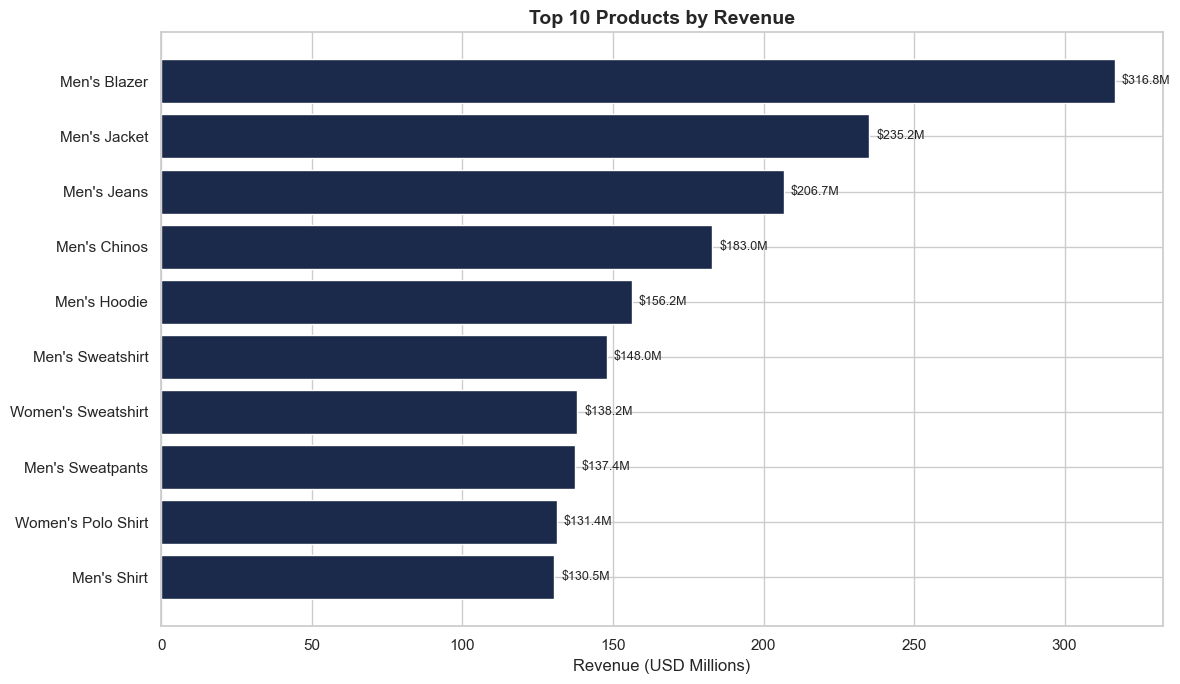

In [6]:
top10 = product.nlargest(10, 'Revenue')

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top10['Name'], top10['Revenue']/1e6, color=NAVY)
ax.bar_label(bars, fmt='$%.1fM', padding=5, fontsize=9)
ax.set_xlabel('Revenue (USD Millions)')
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/02_top_products.png', dpi=150)
plt.show()

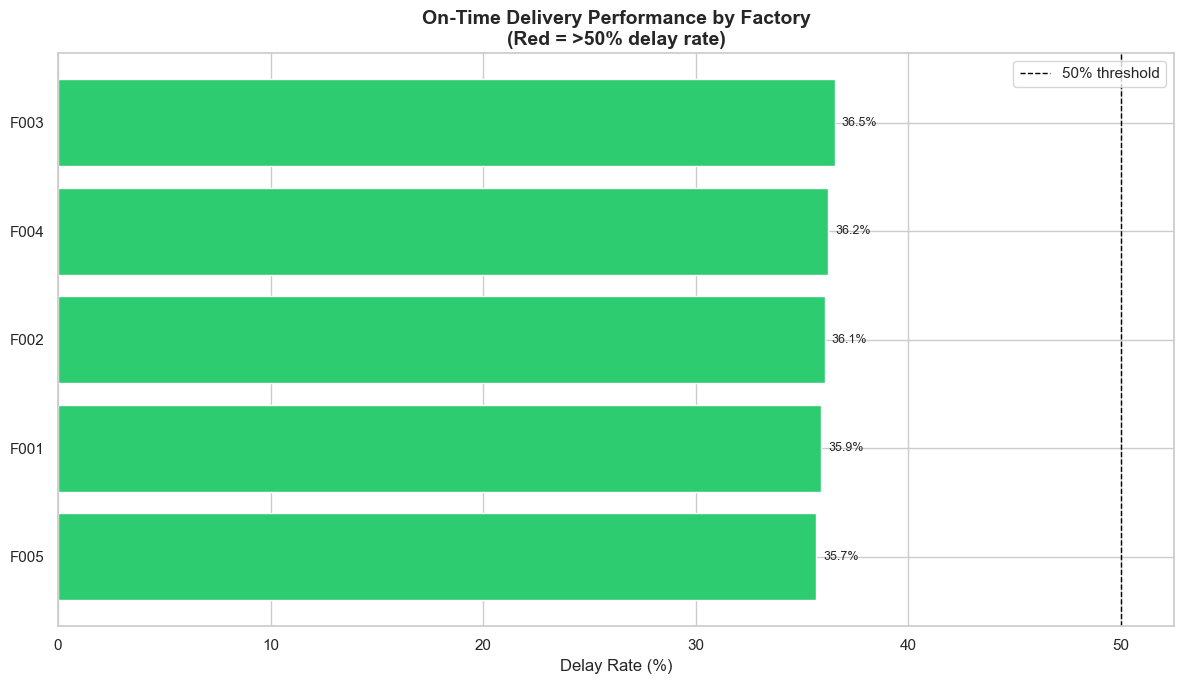

In [7]:
factory_sorted = factory.sort_values('Delay_Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if x > 0.5 else '#2ecc71' for x in factory_sorted['Delay_Rate']]
bars = ax.barh(factory_sorted['Factory_ID'], factory_sorted['Delay_Rate']*100, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=9)
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('On-Time Delivery Performance by Factory\n(Red = >50% delay rate)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_factory_delay.png', dpi=150)
plt.show()

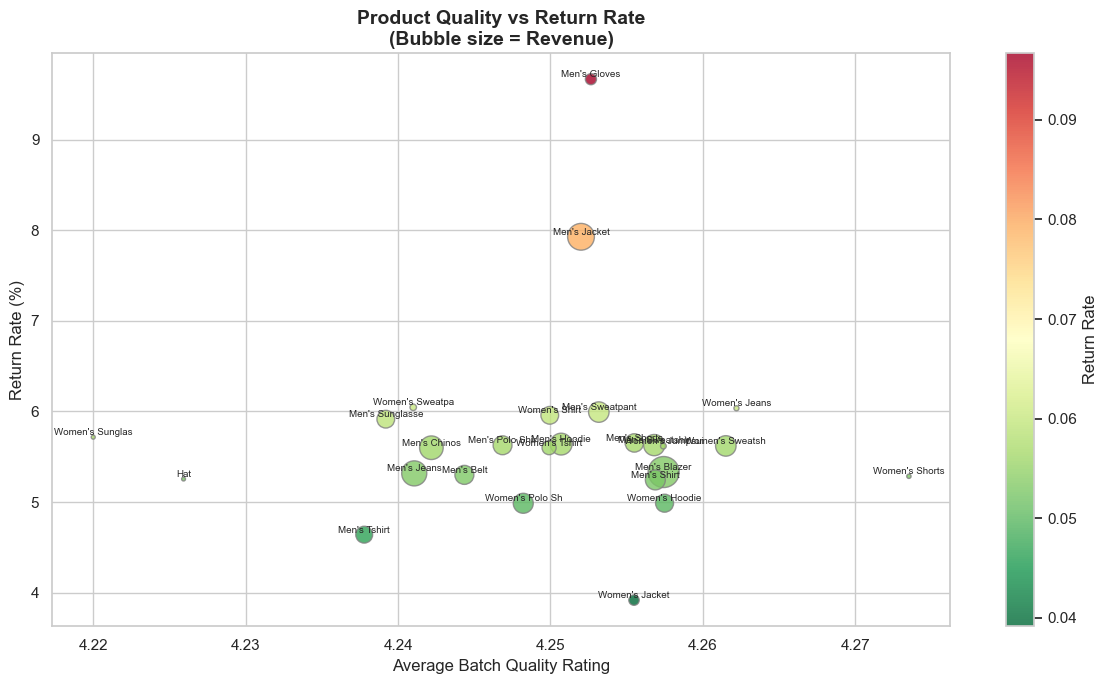

In [8]:
product_detail = df.groupby('Name').agg(
    Return_Rate=('Return_Rate','mean'),
    Avg_Rating=('Avg._Batch_Rating','mean'),
    Revenue=('Total_Revenue','sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    product_detail['Avg_Rating'],
    product_detail['Return_Rate']*100,
    s=product_detail['Revenue']/product_detail['Revenue'].max()*500,
    c=product_detail['Return_Rate'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='grey'
)
for _, row in product_detail.iterrows():
    ax.annotate(row['Name'][:15], (row['Avg_Rating'], row['Return_Rate']*100),
                fontsize=7, ha='center', va='bottom')
ax.set_xlabel('Average Batch Quality Rating')
ax.set_ylabel('Return Rate (%)')
ax.set_title('Product Quality vs Return Rate\n(Bubble size = Revenue)',
             fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Return Rate')
plt.tight_layout()
plt.savefig('../outputs/04_quality_returns.png', dpi=150)
plt.show()

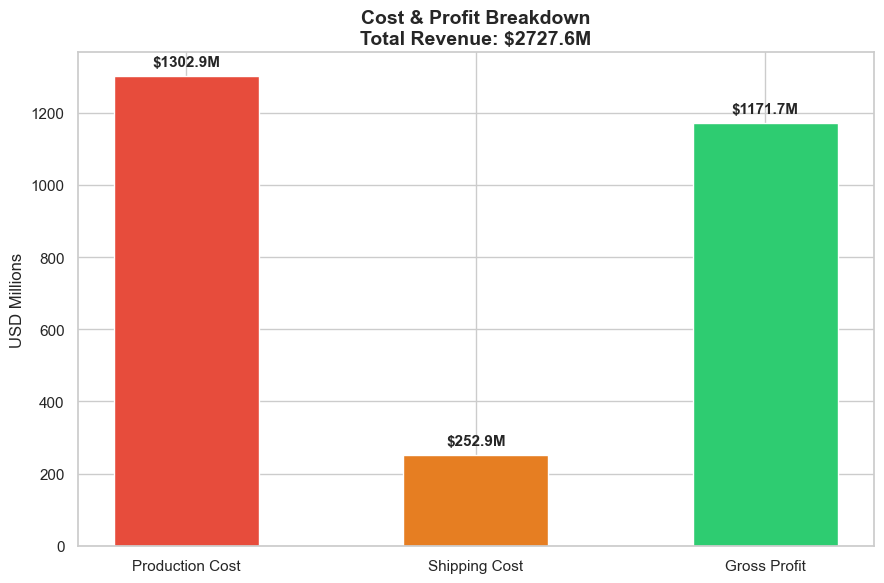

In [9]:
total_prod  = df['Total_Prod_Cost'].sum()
total_ship  = df['Total_Ship_Cost'].sum()
total_rev   = df['Total_Revenue'].sum()
total_profit= df['Gross_Profit'].sum()

labels = ['Production Cost', 'Shipping Cost', 'Gross Profit']
values = [total_prod/1e6, total_ship/1e6, total_profit/1e6]
colors = ['#e74c3c', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.bar_label(bars, fmt='$%.1fM', padding=5, fontsize=11, fontweight='bold')
ax.set_ylabel('USD Millions')
ax.set_title(f'Cost & Profit Breakdown\nTotal Revenue: ${total_rev/1e6:.1f}M',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_cost_breakdown.png', dpi=150)
plt.show()